<a href="https://colab.research.google.com/github/rsouparnika/DL-25-26/blob/main/Program8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

8.	Autoencoders

Objective: Implement different types of autoencoders.

Tasks: Write Python programs to build and train undercomplete, denoising, and variational autoencoders on image data. Explore regularization techniques and representational power.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2452
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1441
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1177
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1038
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0949
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.1462
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1241
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1206
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1186
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1172
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 236.3080
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 185.2173
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 174.5877
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 169.8098
Epo

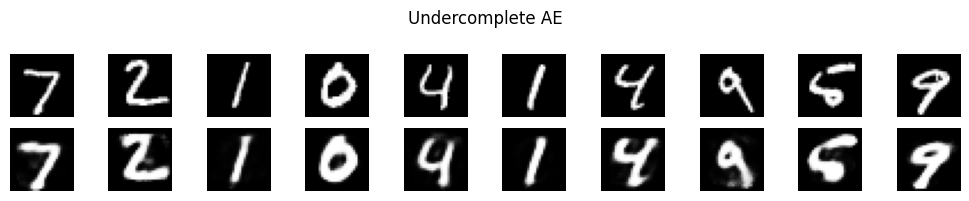

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


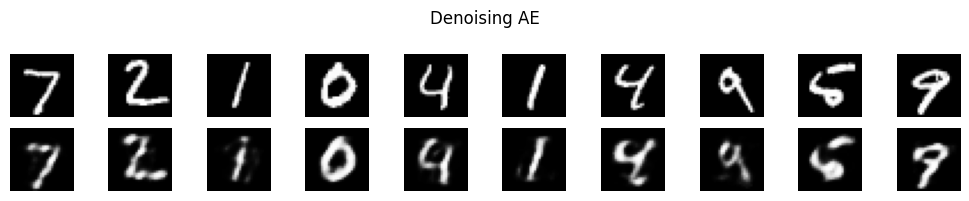

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


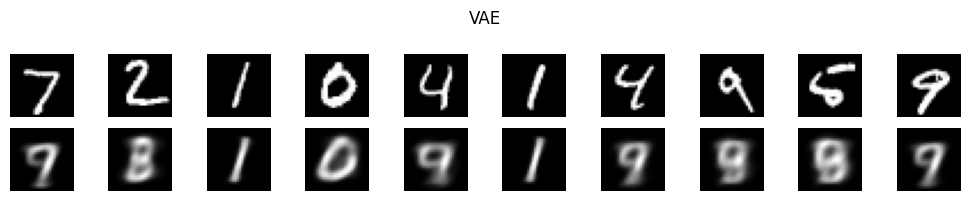

In [ ]:
import numpy as np, tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train.astype("float32") / 255., x_test.astype("float32") / 255.
x_train, x_test = x_train[..., np.newaxis], x_test[..., np.newaxis]

def add_noise(x):
    return np.clip(x + 0.5 * np.random.randn(*x.shape), 0., 1.)

x_train_noisy, x_test_noisy = add_noise(x_train), add_noise(x_test)

enc = models.Sequential([
    layers.Input((28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])

dec = models.Sequential([
    layers.Input((64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

ucae = models.Sequential([enc, dec])
ucae.compile(optimizer='adam', loss='binary_crossentropy')
ucae.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

dnae = models.Sequential([enc, dec])
dnae.compile(optimizer='adam', loss='binary_crossentropy')
dnae.fit(x_train_noisy, x_train, epochs=5, batch_size=256, verbose=1)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(2, name="z_mean")(x)
z_log_var = layers.Dense(2, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = tf.keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = layers.Input(shape=(2,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(784, activation="sigmoid")(x)
outputs = layers.Reshape((28, 28, 1))(x)
decoder = tf.keras.Model(latent_inputs, outputs, name="decoder")

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(inputs, reconstruction)
        ) * 784
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        self.add_loss(recon_loss + kl_loss)
        return reconstruction

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

def show_imgs(orig, recon, title):
    plt.figure(figsize=(10, 2))
    n = min(10, len(orig))
    for i in range(n):
        plt.subplot(2, n, i+1)
        img = orig[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.subplot(2, n, i+n+1)
        img = recon[i].squeeze()
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
show_imgs(x_test, ucae.predict(x_test), "Undercomplete AE")
show_imgs(x_test, dnae.predict(x_test_noisy), "Denoising AE")
show_imgs(x_test, vae.predict(x_test), "VAE")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.2470
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.1434
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1177
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1037
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0948
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.1480
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1243
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - loss: 0.1208
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.1187
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1173
Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 230.6638
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 182.5252
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 173.8288
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 168.7950
E

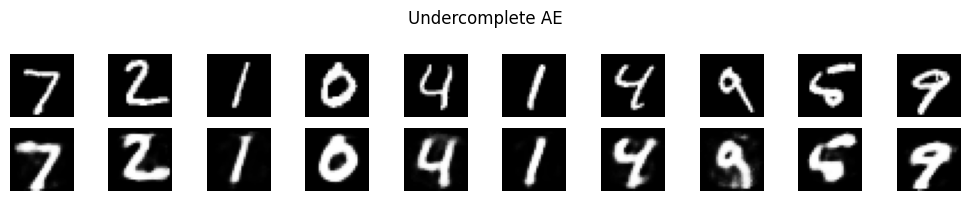

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


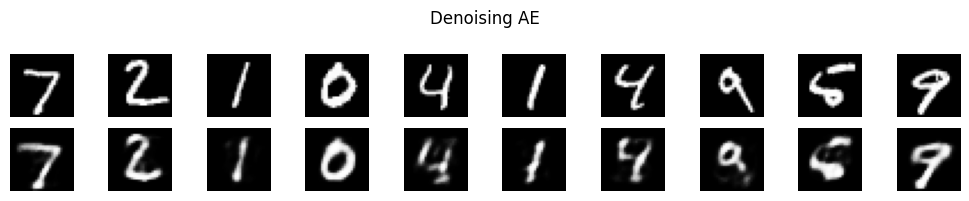

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


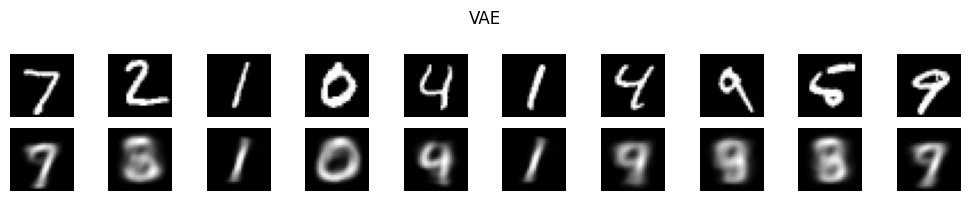

In [ ]:
import numpy as np, tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train.astype("float32") / 255., x_test.astype("float32") / 255.
x_train, x_test = x_train[..., np.newaxis], x_test[..., np.newaxis]

def add_noise(x):
    return np.clip(x + 0.5 * np.random.randn(*x.shape), 0., 1.)

x_train_noisy, x_test_noisy = add_noise(x_train), add_noise(x_test)

enc = models.Sequential([
    layers.Input((28, 28, 1)),
    layers.Flatten(),
    layers.Dense(64, activation='relu')
])
dec = models.Sequential([
    layers.Input((64,)),
    layers.Dense(784, activation='sigmoid'),
    layers.Reshape((28, 28, 1))
])

ucae = models.Sequential([enc, dec])
ucae.compile(optimizer='adam', loss='binary_crossentropy')
ucae.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

dnae = models.Sequential([enc, dec])
dnae.compile(optimizer='adam', loss='binary_crossentropy')
dnae.fit(x_train_noisy, x_train, epochs=5, batch_size=256, verbose=1)

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = layers.Input(shape=(28, 28, 1))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(2, name="z_mean")(x)
z_log_var = layers.Dense(2, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = tf.keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

latent_inputs = layers.Input(shape=(2,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(784, activation="sigmoid")(x)
outputs = layers.Reshape((28, 28, 1))(x)
decoder = tf.keras.Model(latent_inputs, outputs, name="decoder")

class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        recon_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(inputs, reconstruction)) * 784
        kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        self.add_loss(recon_loss + kl_loss)
        return reconstruction

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.fit(x_train, x_train, epochs=5, batch_size=256, verbose=1)

def show_imgs(orig, recon, title):
    plt.figure(figsize=(10, 2))
    n = min(10, len(orig))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        img = orig[i].squeeze() if orig[i].ndim == 3 else orig[i]
        plt.imshow(img, cmap='gray')
        plt.axis('off')

        plt.subplot(2, n, i + n + 1)
        img = recon[i].squeeze() if recon[i].ndim == 3 else recon[i]
        plt.imshow(img, cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_imgs(x_test, ucae.predict(x_test), "Undercomplete AE")
show_imgs(x_test, dnae.predict(x_test_noisy), "Denoising AE")
show_imgs(x_test, vae.predict(x_test), "VAE")